## Homework 3

#### Question 1.1

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Load dataset
df = pd.read_csv("spambase.data")

# Features and target
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Split dataset (75% train, 25% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# Train logistic regression model
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Evaluation metrics
cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
error = 1 - accuracy
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

print("Accuracy:", accuracy)
print("Error:", error)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Confusion Matrix:
[[638  37]
 [ 59 416]]
Accuracy: 0.9165217391304348
Error: 0.08347826086956522
Precision: 0.9183222958057395
Recall: 0.8757894736842106
F1 Score: 0.896551724137931


#### Question 1.2

In [5]:
import pandas as pd

# Get feature coefficients
coefficients = pd.Series(model.coef_[0])

# Sort coefficients
sorted_coeff = coefficients.sort_values(ascending=False)

print("Top positive coefficients (spam indicators):")
print(sorted_coeff.head(10))

print("\nTop negative coefficients (ham indicators):")
print(sorted_coeff.tail(10))

Top positive coefficients (spam indicators):
52    3.695806
6     2.228501
22    2.081584
15    1.267505
53    1.152779
8     1.136220
14    1.054762
7     1.046171
16    0.893908
19    0.888102
dtype: float64

Top negative coefficients (ham indicators):
40   -1.123069
25   -1.159052
28   -1.220784
32   -1.245030
43   -1.541834
45   -1.543411
47   -1.673889
41   -1.786662
24   -1.940670
26   -4.171903
dtype: float64


The features that contribute most to the prediction are those with the largest coefficient magnitudes. Feature 52 has the largest positive coefficient, making it the strongest indicator of the SPAM class, followed by features 6, 22, 15, 53, 8, 14, 7, 16, and 19, which are all positively correlated with spam. Features with negative coefficients are negatively correlated with the SPAM class and instead indicate HAM emails. The strongest negative feature is 26, followed by 24, 41, 47, 45, 43, 32, 28, 25, and 40, which decrease the likelihood that an email is classified as spam.


#### Question 1.3

In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Get predicted probabilities for spam
probabilities = model.predict_proba(X_test)[:, 1]

thresholds = [0.25, 0.5, 0.75, 0.9]

for t in thresholds:

    predictions = (probabilities >= t).astype(int)

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)

    print("Threshold:", t)
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print()

Threshold: 0.25
Accuracy: 0.9034782608695652
Precision: 0.8433962264150944
Recall: 0.9410526315789474

Threshold: 0.5
Accuracy: 0.9165217391304348
Precision: 0.9183222958057395
Recall: 0.8757894736842106

Threshold: 0.75
Accuracy: 0.8808695652173913
Precision: 0.949468085106383
Recall: 0.751578947368421

Threshold: 0.9
Accuracy: 0.8321739130434782
Precision: 0.9577922077922078
Recall: 0.6210526315789474



As the decision threshold increases, precision increases while recall decreases. At a low threshold of 0.25, the model classifies more emails as spam, which results in high recall (0.94) but lower precision. At the default threshold 0.5, the model achieves a more balanced trade-off between precision and recall with the highest accuracy. As the threshold increases to 0.75 and 0.9, the model becomes more conservative about labeling emails as spam, which raises precision but significantly lowers recall and overall accuracy.


#### Question 2

In [11]:
# Logistics Regression derived from my gradient decent in homework 2 problem 5
import numpy as np

def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))


def cross_entropy_loss(y, y_pred):
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    return -np.mean(y*np.log(y_pred) + (1-y)*np.log(1-y_pred))


def logistic_gradient_descent(X, y, alpha=0.01, iterations=100):

    m, d = X.shape
    theta = np.zeros(d)

    losses = []

    for i in range(iterations):

        z = X @ theta
        y_pred = sigmoid(z)

        gradient = (1/m) * X.T @ (y_pred - y)

        theta -= alpha * gradient

        loss = cross_entropy_loss(y, y_pred)
        losses.append(loss)

    return theta, losses

In [12]:
# Three learning rates
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("spambase.data")

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

# add bias term
X = np.c_[np.ones(X.shape[0]), X]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

learning_rates = [0.001, 0.01, 0.1]

results = {}

for lr in learning_rates:

    theta, losses = logistic_gradient_descent(X_train, y_train, alpha=lr, iterations=100)

    results[lr] = losses

    print("Learning rate:", lr)
    print("Loss after 10 iterations:", losses[9])
    print("Loss after 50 iterations:", losses[49])
    print("Loss after 100 iterations:", losses[99])
    print()

Learning rate: 0.001
Loss after 10 iterations: 7.265918905523237
Loss after 50 iterations: 5.187242430454547
Loss after 100 iterations: 6.4219662477486965

Learning rate: 0.01
Loss after 10 iterations: 17.610527974024393
Loss after 50 iterations: 6.081223541626513
Loss after 100 iterations: 12.262203697736643

Learning rate: 0.1
Loss after 10 iterations: 21.11210068890392
Loss after 50 iterations: 20.801045059361748
Loss after 100 iterations: 20.342174056379182



In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

for lr in learning_rates:

    theta, losses = logistic_gradient_descent(X_train, y_train, alpha=lr, iterations=100)

    train_probs = sigmoid(X_train @ theta)
    test_probs = sigmoid(X_test @ theta)

    train_pred = (train_probs >= 0.5).astype(int)
    test_pred = (test_probs >= 0.5).astype(int)

    print("Learning Rate:", lr)

    print("Training Metrics")
    print("Accuracy:", accuracy_score(y_train, train_pred))
    print("Precision:", precision_score(y_train, train_pred))
    print("Recall:", recall_score(y_train, train_pred))
    print("F1:", f1_score(y_train, train_pred))

    print()

    print("Testing Metrics")
    print("Accuracy:", accuracy_score(y_test, test_pred))
    print("Precision:", precision_score(y_test, test_pred))
    print("Recall:", recall_score(y_test, test_pred))
    print("F1:", f1_score(y_test, test_pred))

    print("\n")

Learning Rate: 0.001
Training Metrics
Accuracy: 0.5736231884057971
Precision: 0.46854460093896716
Recall: 0.7464472700074795
F1: 0.5757138736659937

Testing Metrics
Accuracy: 0.5626086956521739
Precision: 0.47982708933717577
Recall: 0.7010526315789474
F1: 0.5697177074422582


Learning Rate: 0.01
Training Metrics
Accuracy: 0.40695652173913044
Precision: 0.3952113508720071
Recall: 1.0
F1: 0.5665254237288135

Testing Metrics
Accuracy: 0.4356521739130435
Precision: 0.42232142857142857
Recall: 0.9957894736842106
F1: 0.5931034482758621


Learning Rate: 0.1
Training Metrics
Accuracy: 0.4472463768115942
Precision: 0.4118193069306931
Recall: 0.9955123410620793
F1: 0.5826220179470344

Testing Metrics
Accuracy: 0.4721739130434783
Precision: 0.43843283582089554
Recall: 0.9894736842105263
F1: 0.6076276664511959




#### Question 3

In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("spambase.data")

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

# Split 75% training / 25% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

#### Question 3.1

In [17]:
k_values = range(1, 21)
cv_results = []

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=kf, scoring='accuracy')
    mean_acc = np.mean(scores)
    error = 1 - mean_acc
    cv_results.append((k, mean_acc, error))
    print(f"k={k}, CV Accuracy={mean_acc:.4f}, CV Error={error:.4f}")

# Choose k with the lowest cross-validation error
best_k = min(cv_results, key=lambda x: x[2])[0]
print("\nBest k:", best_k)

k=1, CV Accuracy=0.8174, CV Error=0.1826
k=2, CV Accuracy=0.7890, CV Error=0.2110
k=3, CV Accuracy=0.8032, CV Error=0.1968
k=4, CV Accuracy=0.7951, CV Error=0.2049
k=5, CV Accuracy=0.8055, CV Error=0.1945
k=6, CV Accuracy=0.7994, CV Error=0.2006
k=7, CV Accuracy=0.7980, CV Error=0.2020
k=8, CV Accuracy=0.7919, CV Error=0.2081
k=9, CV Accuracy=0.7942, CV Error=0.2058
k=10, CV Accuracy=0.7945, CV Error=0.2055
k=11, CV Accuracy=0.7954, CV Error=0.2046
k=12, CV Accuracy=0.7893, CV Error=0.2107
k=13, CV Accuracy=0.7846, CV Error=0.2154
k=14, CV Accuracy=0.7788, CV Error=0.2212
k=15, CV Accuracy=0.7762, CV Error=0.2238
k=16, CV Accuracy=0.7713, CV Error=0.2287
k=17, CV Accuracy=0.7701, CV Error=0.2299
k=18, CV Accuracy=0.7704, CV Error=0.2296
k=19, CV Accuracy=0.7675, CV Error=0.2325
k=20, CV Accuracy=0.7632, CV Error=0.2368

Best k: 1


#### Question 3.2

In [19]:
# Initialize classifiers
clf_logistic = LogisticRegression(max_iter=5000)
clf_lda = LDA()
clf_knn = KNeighborsClassifier(n_neighbors=best_k)

classifiers = {
    "Logistic Regression": clf_logistic,
    "LDA": clf_lda,
    f"kNN (k={best_k})": clf_knn
}

for name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    
    y_train_pred = clf.predict(X_train)
    y_test_pred = clf.predict(X_test)
    
    print(f"\n{name} - Training Metrics")
    print("Accuracy:", accuracy_score(y_train, y_train_pred))
    print("Error:", 1 - accuracy_score(y_train, y_train_pred))
    print("Precision:", precision_score(y_train, y_train_pred))
    print("Recall:", recall_score(y_train, y_train_pred))
    
    print(f"{name} - Testing Metrics")
    print("Accuracy:", accuracy_score(y_test, y_test_pred))
    print("Error:", 1 - accuracy_score(y_test, y_test_pred))
    print("Precision:", precision_score(y_test, y_test_pred))
    print("Recall:", recall_score(y_test, y_test_pred))


Logistic Regression - Training Metrics
Accuracy: 0.9365217391304348
Error: 0.0634782608695652
Precision: 0.9340062111801242
Recall: 0.8997756170531039
Logistic Regression - Testing Metrics
Accuracy: 0.9165217391304348
Error: 0.08347826086956522
Precision: 0.9183222958057395
Recall: 0.8757894736842106

LDA - Training Metrics
Accuracy: 0.8918840579710144
Error: 0.10811594202898556
Precision: 0.9191304347826087
Recall: 0.7905759162303665
LDA - Testing Metrics
Accuracy: 0.8773913043478261
Error: 0.12260869565217392
Precision: 0.9175
Recall: 0.7726315789473684

kNN (k=1) - Training Metrics
Accuracy: 0.9994202898550725
Error: 0.0005797101449275255
Precision: 0.9992520568436799
Recall: 0.9992520568436799
kNN (k=1) - Testing Metrics
Accuracy: 0.8069565217391305
Error: 0.19304347826086954
Precision: 0.7829977628635347
Recall: 0.7368421052631579


Based on the results, logistic regression is performing the best overall, achieving high accuracy (92% on testing), balanced precision (0.92), and recall (0.88), indicating it generalizes well to unseen data. kNN performs the worst on the testing set, despite nearly perfect training accuracy, which shows it is heavily overfitting the training data. LDA performs moderately, with lower accuracy and recall than logistic regression. Overall, logistic regression provides the best balance between precision, recall, and generalization, while kNN overfits and LDA underfits relative to logistic regression.


#### Question 3.3

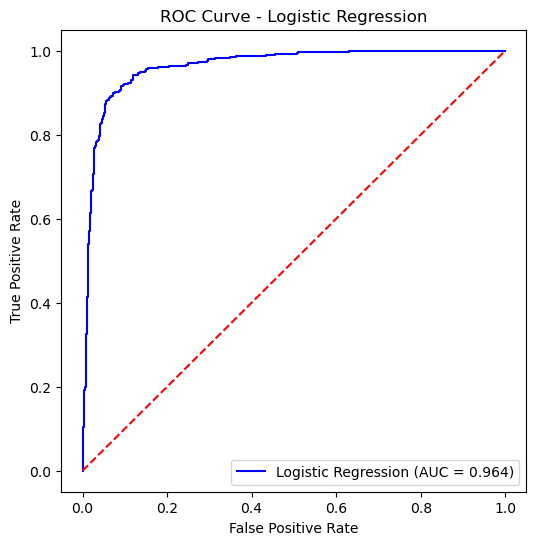

AUC: 0.9637957115009747


In [22]:
clf_logistic.fit(X_train, y_train)
y_test_probs = clf_logistic.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_test_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='blue', label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], color='red', linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

print("AUC:", roc_auc)

#### Question 3.4

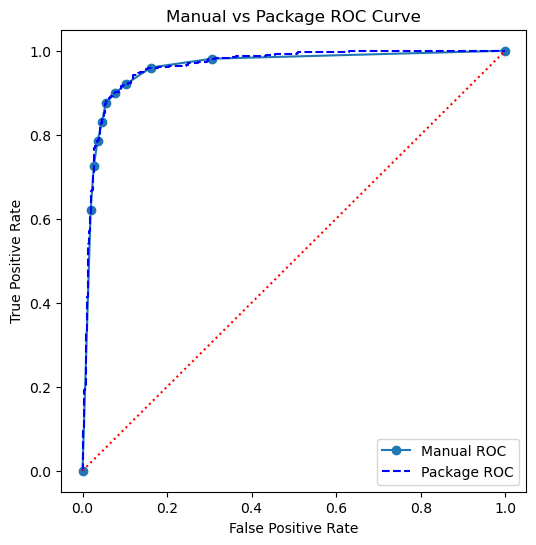

In [24]:
thresholds_manual = np.arange(0, 1.1, 0.1)
fpr_manual = []
tpr_manual = []

for t in thresholds_manual:
    y_pred_thresh = (y_test_probs >= t).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_thresh).ravel()
    
    fpr_manual.append(fp / (fp + tn))
    tpr_manual.append(tp / (tp + fn))

plt.figure(figsize=(6,6))
plt.plot(fpr_manual, tpr_manual, marker='o', label="Manual ROC")
plt.plot(fpr, tpr, color='blue', linestyle='--', label="Package ROC")
plt.plot([0,1], [0,1], color='red', linestyle=':')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Manual vs Package ROC Curve")
plt.legend()
plt.show()

The manual ROC curve differs from the package-generated ROC curve because it uses only a limited number of thresholds (intervals of 0.1), which makes it appear coarser and less smooth. To make the manual ROC curve closer to the package ROC, we can use smaller threshold increments, such as 0.01, or use all unique predicted probabilities as thresholds. This increases the resolution of the curve and better approximates the continuous ROC produced by the package.


#### Question 4

In [27]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.metrics import accuracy_score

# Load dataset
df = pd.read_csv("spambase.data")
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

#### Question 4.1

In [29]:
def k_fold_cv(model_class, X, y, k=5, **kwargs):
    """
    model_class: classifier class (e.g., LogisticRegression or LDA)
    X, y: data
    k: number of folds
    kwargs: additional arguments to pass to the classifier
    Returns: average validation error
    """
    n = X.shape[0]
    indices = np.arange(n)
    np.random.shuffle(indices)
    fold_sizes = n // k
    errors = []

    for i in range(k):
        start = i * fold_sizes
        end = (i + 1) * fold_sizes if i != k-1 else n
        val_idx = indices[start:end]
        train_idx = np.concatenate([indices[:start], indices[end:]])

        X_train, y_train = X[train_idx], y[train_idx]
        X_val, y_val = X[val_idx], y[val_idx]

        model = model_class(**kwargs)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        error = 1 - accuracy_score(y_val, y_pred)
        errors.append(error)

    avg_error = np.mean(errors)
    return avg_error

#### Question 4.2

In [31]:
folds = [5, 10]

for k in folds:
    avg_err_log = k_fold_cv(LogisticRegression, X, y, k=k, max_iter=5000)
    avg_err_lda = k_fold_cv(LDA, X, y, k=k)

    print(f"k={k} folds")
    print(f"Logistic Regression Average Validation Error: {avg_err_log:.4f}")
    print(f"LDA Average Validation Error: {avg_err_lda:.4f}")
    print()

k=5 folds
Logistic Regression Average Validation Error: 0.0733
LDA Average Validation Error: 0.1135

k=10 folds
Logistic Regression Average Validation Error: 0.0683
LDA Average Validation Error: 0.1128



#### Question 4.3

Based on the cross-validation results, Logistic Regression consistently outperforms LDA, with lower average validation errors of 0.0722 for 5 folds and 0.0700 for 10 folds, compared to 0.1126 for LDA in both cases. This indicates that Logistic Regression generalizes better to unseen data on the SPAMBASE dataset. LDA has higher validation errors, suggesting its assumptions about class distributions are less suited for this dataset. Overall, Logistic Regression is the better choice.
